# Heart Disease Prediction

## 1. Project Overview

### Problem Statement
The goal of this project is to build a Machine Learning model
that predicts whether a patient has heart disease based on
their clinical features.

### Machine Learning Problem
This is a Supervised Learning problem.

The target variable represents whether heart disease is present
or absent, so this is a Binary Classification problem.

### Objective
Build an end-to-end Machine Learning solution that:
- Understands and analyzes the dataset.
- Performs data cleaning and preprocessing.
- Applies Logistic Regression.
- Evaluates the model using appropriate classification metrics.
- Performs error analysis.
- Saves the trained model pipeline.
- Deploys the model using Streamlit.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "mdzawharulislam/uci-processedclevelanddata"
)

print("Path to dataset files:", path)

100%|██████████| 3.42k/3.42k [00:00<00:00, 3.74MB/s]

Extracting files...
Path to dataset files: C:\Users\Abdel\.cache\kagglehub\datasets\mdzawharulislam\uci-processedclevelanddata\versions\1


In [2]:
from pathlib import Path
import shutil

raw_dir = Path("../data/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

download_dir = Path(path)

for file in download_dir.iterdir():
    if file.is_file():
        shutil.copy2(file, raw_dir / file.name)

print("Raw data saved to:", raw_dir.resolve())
print("Files:", [f.name for f in raw_dir.iterdir()])

Raw data saved to: C:\PROJECT\ML_PROJECT\Heart-disease-project\data\raw
Files: ['heart_disease_data.csv']


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from pathlib import Path

data_path = Path("../data/raw/heart_disease_data.csv")

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (303, 14)


In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [10]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [11]:
df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [12]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [13]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [14]:

df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [15]:
df["target"].value_counts(normalize=True) * 100

target
1    54.455446
0    45.544554
Name: proportion, dtype: float64

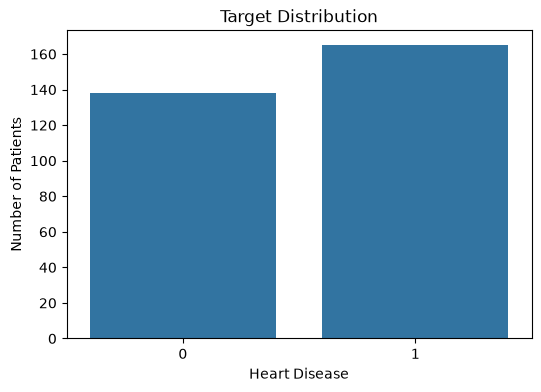

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()


In [17]:
df["target"].value_counts().sort_index()

target
0    138
1    165
Name: count, dtype: int64

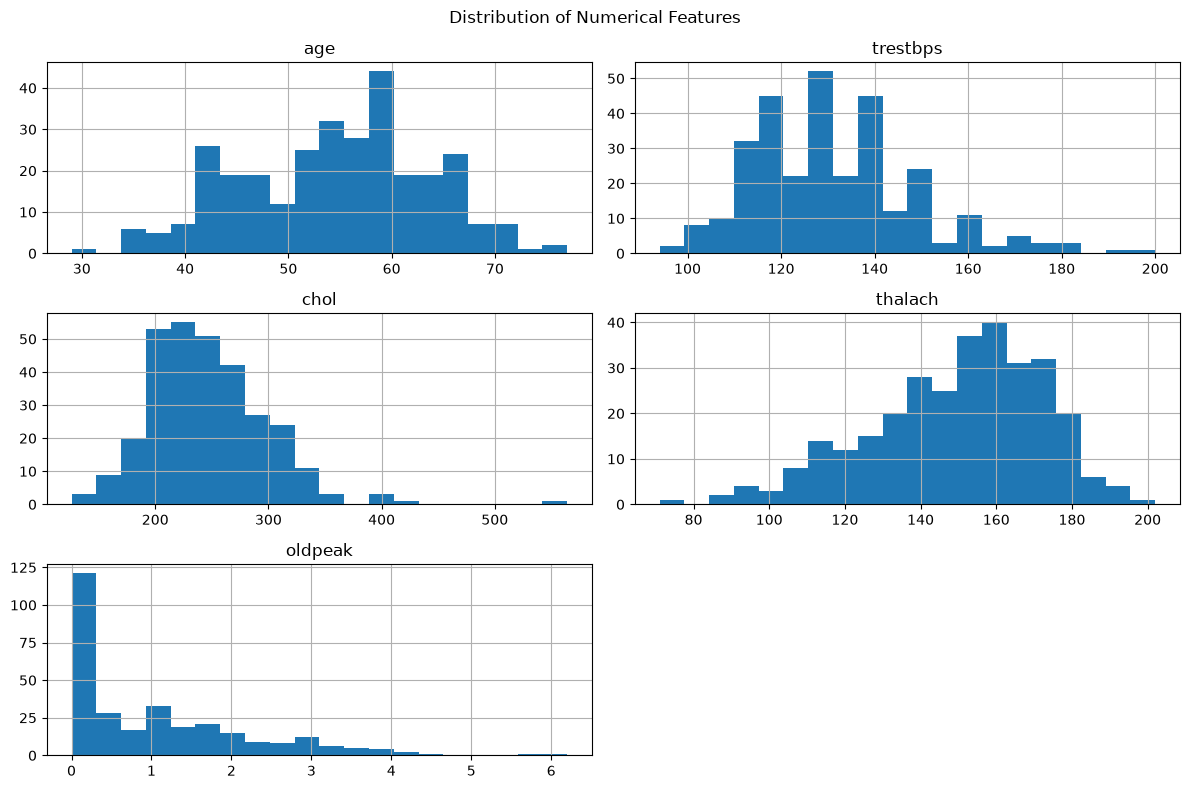

In [18]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df[numerical_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

In [19]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

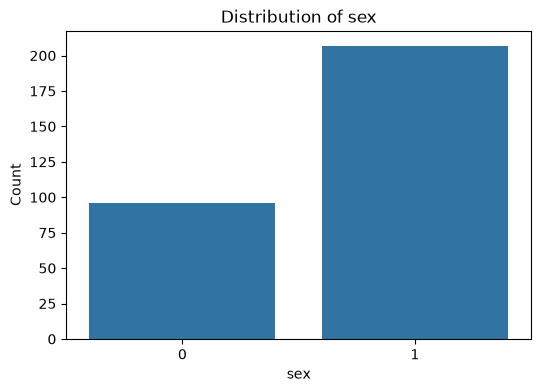

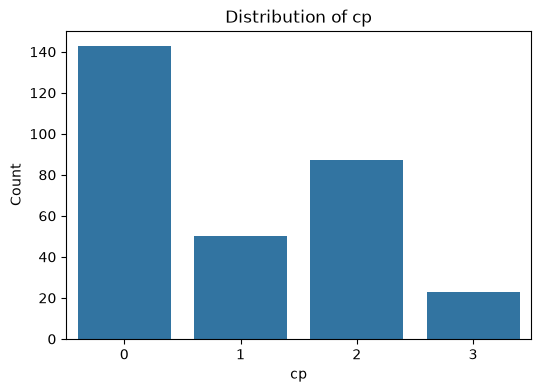

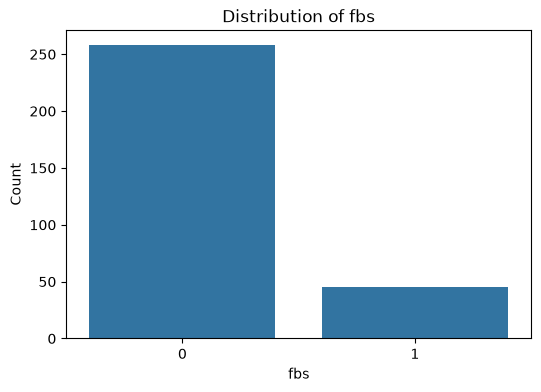

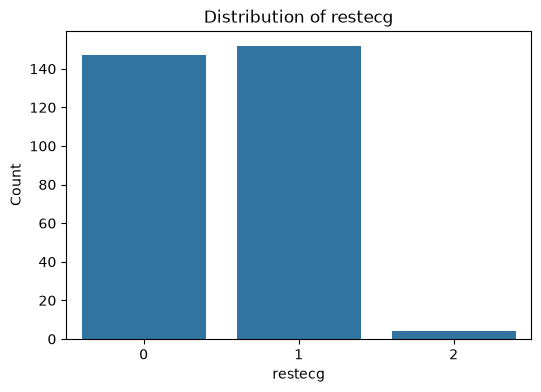

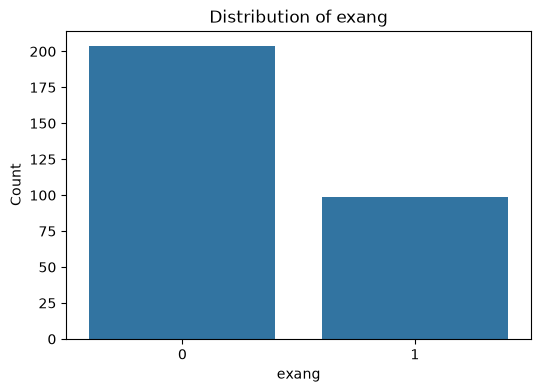

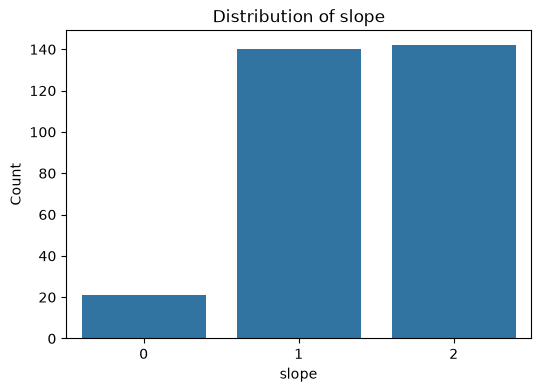

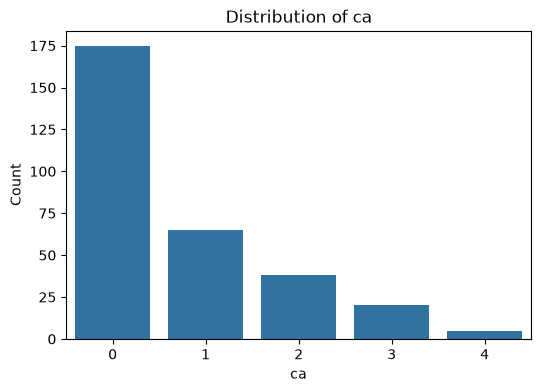

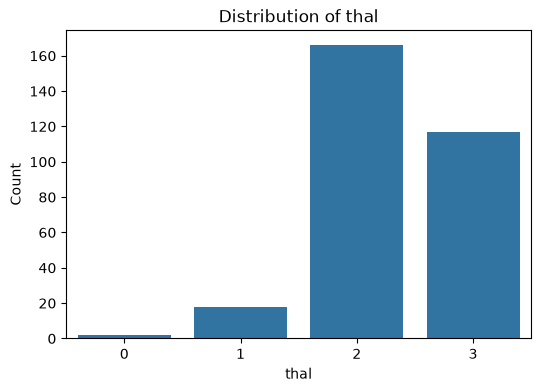

In [20]:
for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=feature)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

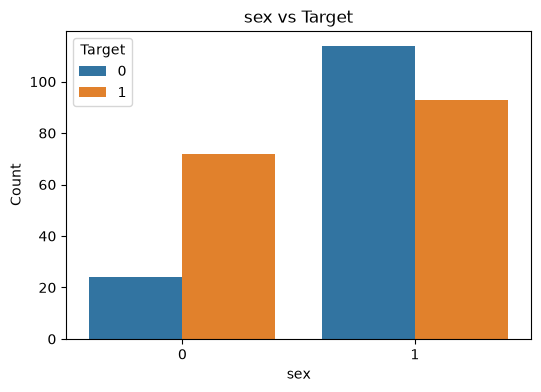

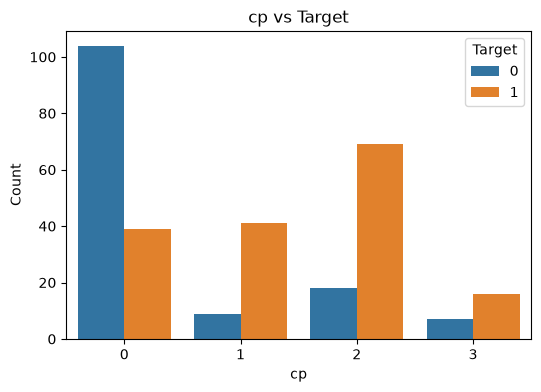

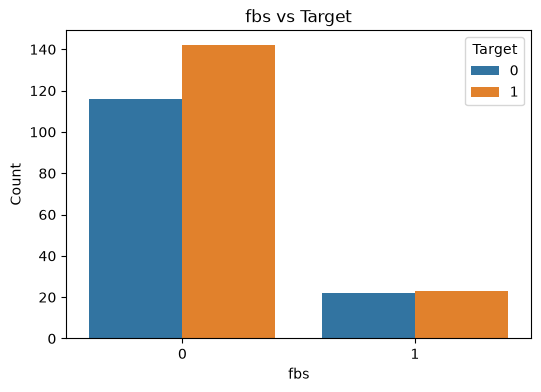

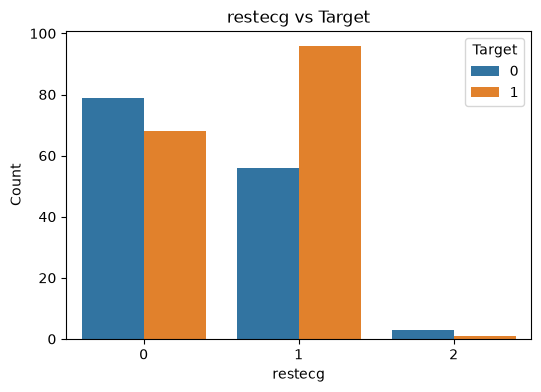

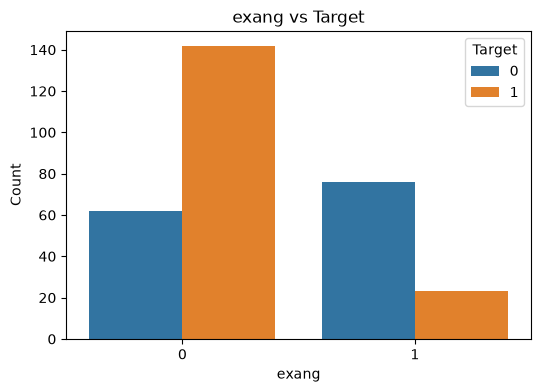

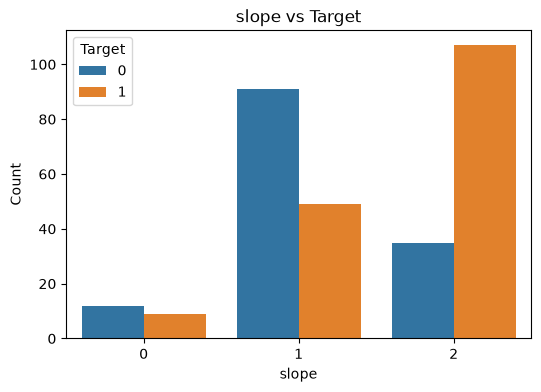

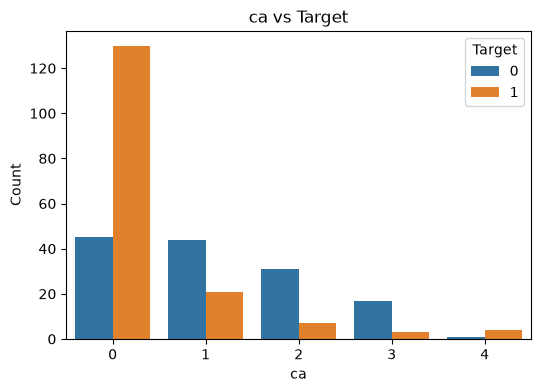

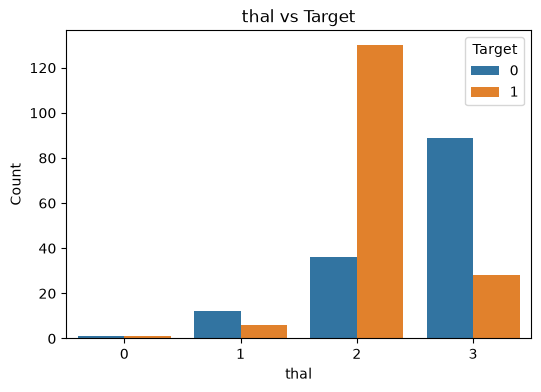

In [21]:
for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=feature, hue="target")
    plt.title(f"{feature} vs Target")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend(title="Target")
    plt.show()

In [22]:
for feature in categorical_features:
    print(f"\n{feature}")
    print(
        pd.crosstab(
            df[feature],
            df["target"],
            normalize="index"
        ).round(2)
    )
    


sex
target     0     1
sex               
0       0.25  0.75
1       0.55  0.45

cp
target     0     1
cp                
0       0.73  0.27
1       0.18  0.82
2       0.21  0.79
3       0.30  0.70

fbs
target     0     1
fbs               
0       0.45  0.55
1       0.49  0.51

restecg
target      0     1
restecg            
0        0.54  0.46
1        0.37  0.63
2        0.75  0.25

exang
target     0     1
exang             
0       0.30  0.70
1       0.77  0.23

slope
target     0     1
slope             
0       0.57  0.43
1       0.65  0.35
2       0.25  0.75

ca
target     0     1
ca                
0       0.26  0.74
1       0.68  0.32
2       0.82  0.18
3       0.85  0.15
4       0.20  0.80

thal
target     0     1
thal              
0       0.50  0.50
1       0.67  0.33
2       0.22  0.78
3       0.76  0.24


In [23]:
for feature in categorical_features:
    percentage = (
        df.groupby(feature)["target"]
        .mean()
        .mul(100)
        .round(2)
    )

    print(f"\n{feature}")
    print(percentage)


sex
sex
0    75.00
1    44.93
Name: target, dtype: float64

cp
cp
0    27.27
1    82.00
2    79.31
3    69.57
Name: target, dtype: float64

fbs
fbs
0    55.04
1    51.11
Name: target, dtype: float64

restecg
restecg
0    46.26
1    63.16
2    25.00
Name: target, dtype: float64

exang
exang
0    69.61
1    23.23
Name: target, dtype: float64

slope
slope
0    42.86
1    35.00
2    75.35
Name: target, dtype: float64

ca
ca
0    74.29
1    32.31
2    18.42
3    15.00
4    80.00
Name: target, dtype: float64

thal
thal
0    50.00
1    33.33
2    78.31
3    23.93
Name: target, dtype: float64


In [24]:
df.groupby(feature)["target"].mean()

thal
0    0.500000
1    0.333333
2    0.783133
3    0.239316
Name: target, dtype: float64

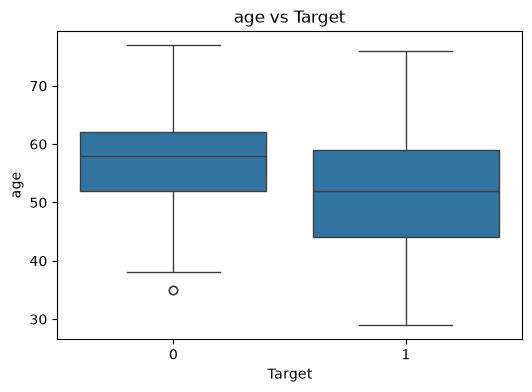

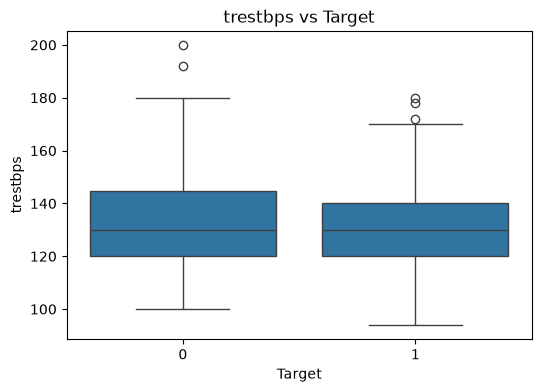

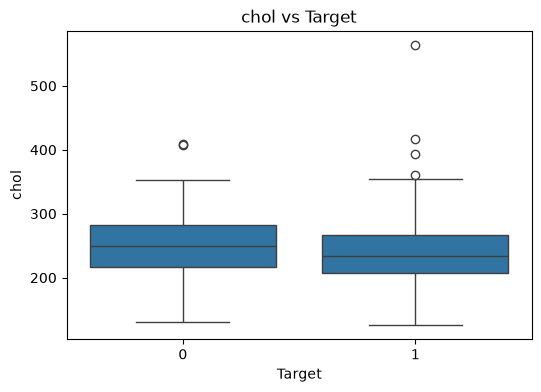

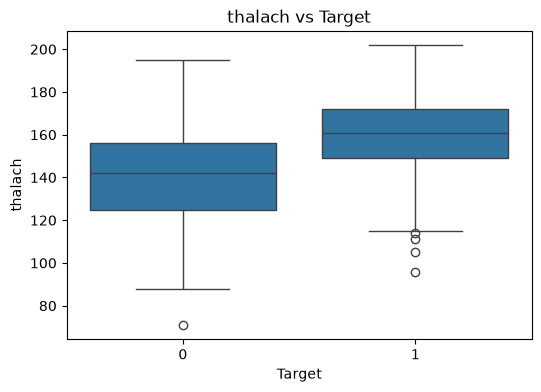

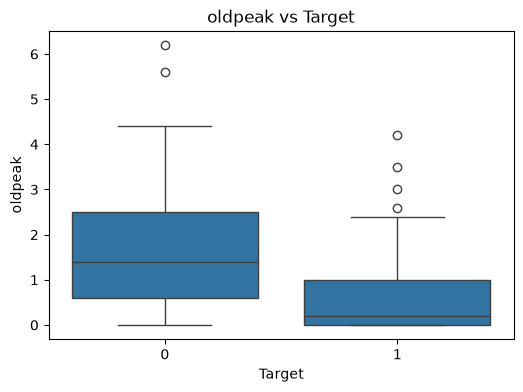

In [25]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="target", y=feature)
    plt.title(f"{feature} vs Target")
    plt.xlabel("Target")
    plt.ylabel(feature)
    plt.show()

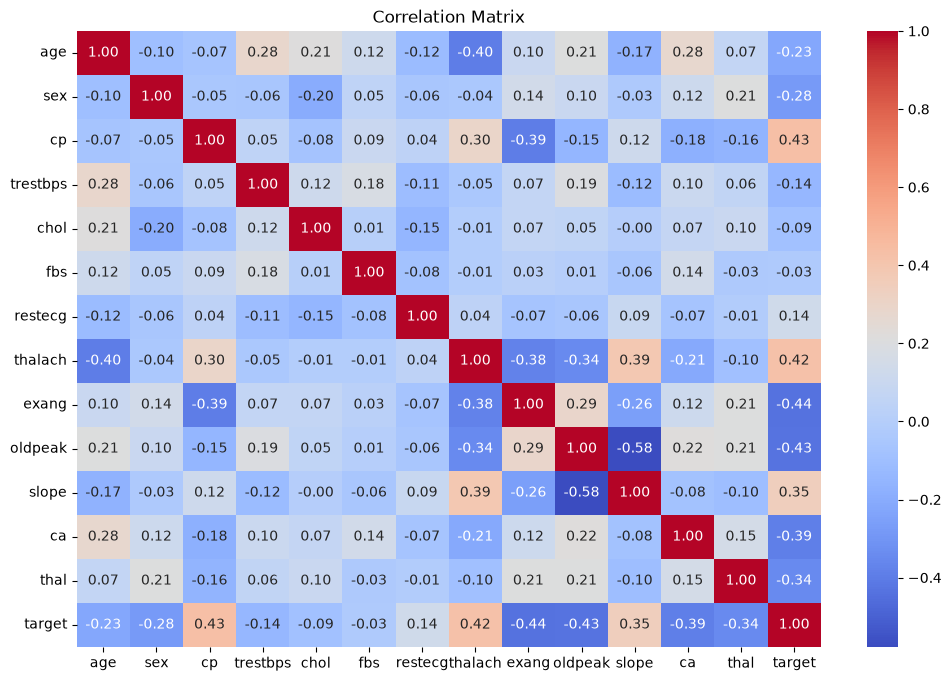

In [26]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [27]:
X = df.drop("target", axis=1)
y = df["target"]

In [28]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (242, 13)
X_test shape: (61, 13)
y_train shape: (242,)
y_test shape: (61,)


In [32]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

In [31]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [34]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [38]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (242, 26)
X_test_processed shape: (61, 26)


In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [41]:
model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [42]:
y_pred = model.predict(X_test_processed)

print(y_pred)

[0 0 0 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 0 0 0 1 1
 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1]


In [43]:
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

print(y_pred_proba)

[0.04086501 0.12932523 0.00826273 0.82476332 0.59567019 0.06910998
 0.93612405 0.30307978 0.9841722  0.42272348 0.11201038 0.60326116
 0.07023625 0.97249741 0.9850305  0.82499152 0.96836855 0.70000637
 0.73005741 0.67846679 0.8252311  0.13427723 0.94068946 0.92026523
 0.94692428 0.02154269 0.12545668 0.54122383 0.22840336 0.89321917
 0.07832398 0.84843109 0.40108265 0.0941161  0.00599538 0.53747193
 0.50081806 0.93961309 0.96892965 0.09405621 0.31455635 0.93680917
 0.98765996 0.62120566 0.12371594 0.33525283 0.95128354 0.58891563
 0.67761244 0.92020795 0.6235388  0.89641558 0.49201208 0.01413212
 0.94265412 0.98172757 0.94666126 0.62438456 0.03054709 0.05205648
 0.91332363]


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.8032786885245902
Precision: 0.7837837837837838
Recall   : 0.8787878787878788
F1 Score : 0.8285714285714286
ROC-AUC  : 0.8841991341991342


In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[20  8]
 [ 4 29]]


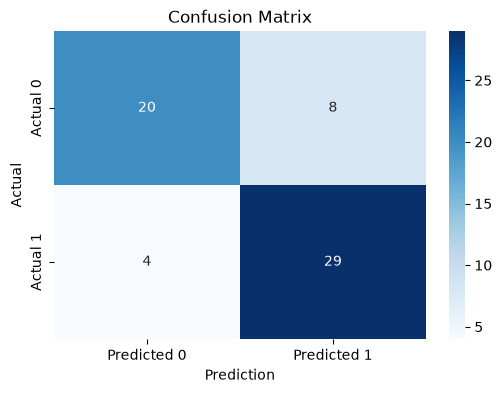

In [46]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

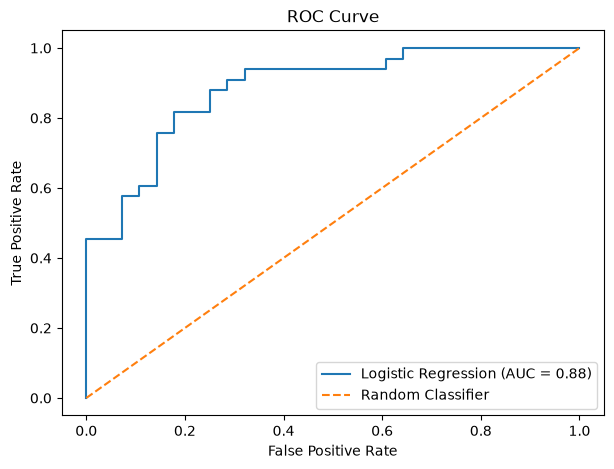

In [47]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [48]:
errors = X_test.copy()

errors["actual"] = y_test
errors["predicted"] = y_pred
errors["probability"] = y_pred_proba

errors = errors[errors["actual"] != errors["predicted"]]

print("Number of errors:", len(errors))
errors

Number of errors: 12


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,actual,predicted,probability
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2,0,1,0.824763
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0,1,0.595670
95,53,1,0,142,226,0,0,111,1,0.0,2,0,3,1,0,0.112010
267,49,1,2,118,149,0,0,126,0,0.8,2,3,2,0,1,0.825231
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0,1,0.920265
51,66,1,0,120,302,0,0,151,0,0.4,1,0,2,1,0,0.401083
185,44,1,0,112,290,0,0,153,0,0.0,2,1,2,0,1,0.500818
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1,0,0.094056
293,67,1,2,152,212,0,0,150,0,0.8,1,0,3,0,1,0.588916
286,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0,1,0.920208


In [49]:
false_positives = errors[
    (errors["actual"] == 0) &
    (errors["predicted"] == 1)
]

false_negatives = errors[
    (errors["actual"] == 1) &
    (errors["predicted"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

print("\nFalse Positives:")
display(false_positives)

print("\nFalse Negatives:")
display(false_negatives)

False Positives: 8
False Negatives: 4

False Positives:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,actual,predicted,probability
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2,0,1,0.824763
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0,1,0.595670
267,49,1,2,118,149,0,0,126,0,0.8,2,3,2,0,1,0.825231
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0,1,0.920265
185,44,1,0,112,290,0,0,153,0,0.0,2,1,2,0,1,0.500818
293,67,1,2,152,212,0,0,150,0,0.8,1,0,3,0,1,0.588916
286,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0,1,0.920208
271,61,1,3,134,234,0,1,145,0,2.6,1,2,2,0,1,0.623539



False Negatives:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,actual,predicted,probability
95,53,1,0,142,226,0,0,111,1,0.0,2,0,3,1,0,0.112010
51,66,1,0,120,302,0,0,151,0,0.4,1,0,2,1,0,0.401083
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1,0,0.094056
83,52,1,3,152,298,1,1,178,0,1.2,1,0,3,1,0,0.492012


In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds_to_test:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print("-" * 30)

Threshold: 0.3
Precision: 0.721
Recall:    0.939
F1 Score:  0.816
------------------------------
Threshold: 0.4
Precision: 0.775
Recall:    0.939
F1 Score:  0.849
------------------------------
Threshold: 0.5
Precision: 0.784
Recall:    0.879
F1 Score:  0.829
------------------------------
Threshold: 0.6
Precision: 0.844
Recall:    0.818
F1 Score:  0.831
------------------------------
Threshold: 0.7
Precision: 0.846
Recall:    0.667
F1 Score:  0.746
------------------------------


In [51]:
from sklearn.pipeline import Pipeline

In [52]:
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [53]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere no

In [54]:
y_pred_final = final_pipeline.predict(X_test)

y_pred_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

In [55]:
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
roc_auc_final = roc_auc_score(y_test, y_pred_proba_final)

print("Final Model Performance")
print("-" * 30)
print(f"Accuracy : {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall   : {recall_final:.4f}")
print(f"F1 Score : {f1_final:.4f}")
print(f"ROC-AUC  : {roc_auc_final:.4f}")

Final Model Performance
------------------------------
Accuracy : 0.8033
Precision: 0.7838
Recall   : 0.8788
F1 Score : 0.8286
ROC-AUC  : 0.8842


In [56]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

C_values = [0.01, 0.1, 0.5, 1, 2, 5, 10, 100]

results = []

for C in C_values:

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(
                C=C,
                max_iter=1000,
                random_state=42
            ))
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        }
    )

    results.append({
        "C": C,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results)

results_df

,C,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.01,0.826276,0.797407,0.916239,0.852534,0.894082
1,0.10,0.838605,0.829809,0.885755,0.856538,0.895312
2,0.50,0.809609,0.815363,0.839886,0.826255,0.887542
3,1.00,0.813776,0.817696,0.847578,0.831431,0.881313
4,2.00,0.805527,0.806000,0.847578,0.825470,0.876897
5,5.00,0.805442,0.804458,0.847293,0.824226,0.870694
6,10.00,0.801361,0.803538,0.839886,0.820341,0.868622
7,100.00,0.801361,0.803538,0.839886,0.820341,0.867262


In [57]:
best_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            C=0.1,
            max_iter=1000,
            random_state=42
        ))
    ]
)

best_pipeline.fit(X_train, y_train)

y_pred_best = best_pipeline.predict(X_test)
y_pred_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

In [58]:
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)

print(f"Accuracy : {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall   : {recall_best:.4f}")
print(f"F1 Score : {f1_best:.4f}")
print(f"ROC-AUC  : {roc_auc_best:.4f}")

Accuracy : 0.8525
Precision: 0.8158
Recall   : 0.9394
F1 Score : 0.8732
ROC-AUC  : 0.8994


[[21  7]
 [ 2 31]]


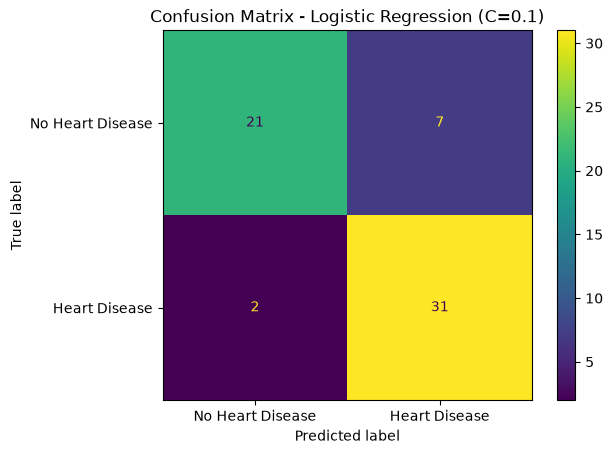

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_best = confusion_matrix(y_test, y_pred_best)

print(cm_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression (C=0.1)")
plt.show()

In [60]:
errors_best = X_test.copy()

errors_best["actual"] = y_test
errors_best["predicted"] = y_pred_best
errors_best["probability"] = y_pred_proba_best

errors_best = errors_best[
    errors_best["actual"] != errors_best["predicted"]
]

print("Number of errors:", len(errors_best))

errors_best

Number of errors: 9


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,actual,predicted,probability
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2,0,1,0.707844
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0,1,0.589328
95,53,1,0,142,226,0,0,111,1,0.0,2,0,3,1,0,0.222430
267,49,1,2,118,149,0,0,126,0,0.8,2,3,2,0,1,0.703407
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0,1,0.859768
185,44,1,0,112,290,0,0,153,0,0.0,2,1,2,0,1,0.615840
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1,0,0.232415
293,67,1,2,152,212,0,0,150,0,0.8,1,0,3,0,1,0.554548
286,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0,1,0.803782


In [62]:
numerical_features_v2 = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [61]:
categorical_features_v2 = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [63]:
preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_v2
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_v2
        )
    ]
)

In [64]:
pipeline_v2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v2),
        (
            "model",
            LogisticRegression(
                C=0.1,
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [65]:
pipeline_v2.fit(X_train, y_train)

y_pred_v2 = pipeline_v2.predict(X_test)
y_pred_proba_v2 = pipeline_v2.predict_proba(X_test)[:, 1]

accuracy_v2 = accuracy_score(y_test, y_pred_v2)
precision_v2 = precision_score(y_test, y_pred_v2)
recall_v2 = recall_score(y_test, y_pred_v2)
f1_v2 = f1_score(y_test, y_pred_v2)
roc_auc_v2 = roc_auc_score(y_test, y_pred_proba_v2)

print(f"Accuracy : {accuracy_v2:.4f}")
print(f"Precision: {precision_v2:.4f}")
print(f"Recall   : {recall_v2:.4f}")
print(f"F1 Score : {f1_v2:.4f}")
print(f"ROC-AUC  : {roc_auc_v2:.4f}")

Accuracy : 0.8689
Precision: 0.8378
Recall   : 0.9394
F1 Score : 0.8857
ROC-AUC  : 0.9048


In [66]:
cv_v2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_v2 = cross_validate(
    pipeline_v2,
    X_train,
    y_train,
    cv=cv_v2,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
)

print(f"CV Accuracy : {scores_v2['test_accuracy'].mean():.4f}")
print(f"CV Precision: {scores_v2['test_precision'].mean():.4f}")
print(f"CV Recall   : {scores_v2['test_recall'].mean():.4f}")
print(f"CV F1       : {scores_v2['test_f1'].mean():.4f}")
print(f"CV ROC-AUC  : {scores_v2['test_roc_auc'].mean():.4f}")

CV Accuracy : 0.8264
CV Precision: 0.8371
CV Recall   : 0.8484
CV F1       : 0.8421
CV ROC-AUC  : 0.8960


In [67]:
feature_names = pipeline_v2.named_steps["preprocessor"].get_feature_names_out()

coefficients = pipeline_v2.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient,Absolute_Coefficient
7,cat__cp_0,-0.653082,0.653082
21,cat__ca_0,0.552394,0.552394
28,cat__thal_2,0.547823,0.547823
29,cat__thal_3,-0.529753,0.529753
4,num__oldpeak,-0.403891,0.403891
9,cat__cp_2,0.379218,0.379218
17,cat__exang_1,-0.310049,0.310049
16,cat__exang_0,0.309990,0.309990
6,cat__sex_1,-0.305651,0.305651
5,cat__sex_0,0.305592,0.305592


In [68]:
preprocessor_ca_num = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            [
                "age",
                "trestbps",
                "chol",
                "thalach",
                "oldpeak",
                "ca"
            ]
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            [
                "sex",
                "cp",
                "fbs",
                "restecg",
                "exang",
                "slope",
                "thal"
            ]
        )
    ]
)

In [69]:
preprocessor_ca_cat = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            [
                "age",
                "trestbps",
                "chol",
                "thalach",
                "oldpeak"
            ]
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            [
                "sex",
                "cp",
                "fbs",
                "restecg",
                "exang",
                "slope",
                "ca",
                "thal"
            ]
        )
    ]
)

In [70]:
grid_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_ca_cat),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [71]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        "preprocessor": [
            preprocessor_ca_num,
            preprocessor_ca_cat
        ],
        "model__C": [
            0.01,
            0.05,
            0.1,
            0.2,
            0.5,
            1,
            2
        ]
    }
]

grid_search = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.01, 0.05, ...], 'preprocessor': [ColumnTransfo...e', 'thal'])]), ColumnTransfo...a', 'thal'])])]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for call

In [72]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(f"{grid_search.best_score_:.4f}")

Best Parameters:
{'model__C': 0.2, 'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])}

Best CV ROC-AUC:
0.8982


In [73]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results = grid_results[
    [
        "param_preprocessor",
        "param_model__C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

grid_results

,param_preprocessor,param_model__C,mean_test_score,std_test_score,rank_test_score
7,"ColumnTransformer(transformers=[('num', Standa...",0.20,0.898226,0.044357,1
3,"ColumnTransformer(transformers=[('num', Standa...",0.05,0.897643,0.055498,2
9,"ColumnTransformer(transformers=[('num', Standa...",0.50,0.896892,0.042074,3
2,"ColumnTransformer(transformers=[('num', Standa...",0.05,0.896296,0.053546,4
5,"ColumnTransformer(transformers=[('num', Standa...",0.10,0.896037,0.051836,5
4,"ColumnTransformer(transformers=[('num', Standa...",0.10,0.895312,0.050465,6
0,"ColumnTransformer(transformers=[('num', Standa...",0.01,0.894082,0.057862,7
1,"ColumnTransformer(transformers=[('num', Standa...",0.01,0.893693,0.061575,8
6,"ColumnTransformer(transformers=[('num', Standa...",0.20,0.892269,0.046708,9
11,"ColumnTransformer(transformers=[('num', Standa...",1.00,0.890365,0.035527,10


In [74]:
final_candidate = grid_search.best_estimator_

print("Best C:", grid_search.best_params_["model__C"])
print("Best CV ROC-AUC:", grid_search.best_score_)

Best C: 0.2
Best CV ROC-AUC: 0.8982258482258482


In [75]:
y_pred_final = final_candidate.predict(X_test)
y_pred_proba_final = final_candidate.predict_proba(X_test)[:, 1]

In [76]:
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
roc_auc_final = roc_auc_score(y_test, y_pred_proba_final)

print(f"Accuracy : {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall   : {recall_final:.4f}")
print(f"F1 Score : {f1_final:.4f}")
print(f"ROC-AUC  : {roc_auc_final:.4f}")

Accuracy : 0.8852
Precision: 0.8611
Recall   : 0.9394
F1 Score : 0.8986
ROC-AUC  : 0.9113


[[23  5]
 [ 2 31]]


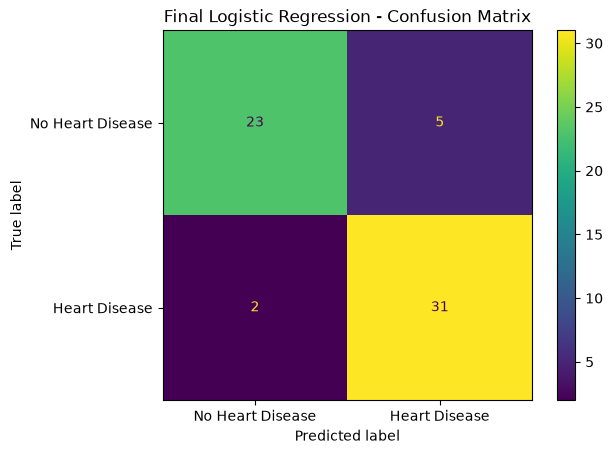

In [77]:
cm_final = confusion_matrix(y_test, y_pred_final)

print(cm_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp.plot()
plt.title("Final Logistic Regression - Confusion Matrix")
plt.show()

In [78]:
roc_auc_final = roc_auc_score(y_test, y_pred_proba_final)

print(f"ROC-AUC: {roc_auc_final:.4f}")

ROC-AUC: 0.9113


In [79]:
import joblib
import os

model_path = "../models/heart_disease_logistic_pipeline.pkl"

os.makedirs("../models", exist_ok=True)

joblib.dump(final_candidate, model_path)

print(f"Final model saved successfully at: {model_path}")

Final model saved successfully at: ../models/heart_disease_logistic_pipeline.pkl
